# **SPECTRA-CQ: Synthetic Anomaly Evaluation (Single-Sensor `PE11`)**

## **Objective:**
Evaluate the empirical anomaly detection threshold of localized Structural Health Monitoring (SHM) architectures prior to multi-sensor spatial fusion.

To rigorously account for the optimization volatility of Noisy Intermediate-Scale Quantum (NISQ) algorithms and prevent initialization bias, this evaluation strictly adheres to an **Ensemble Averaging Protocol**.

The inference loop computes the Mean Squared Error (MSE) reconstruction loss across three deterministic seeds (`42`, `100`, `2026`) for every tested architecture and degradation level. The final Area Under the Receiver Operating Characteristic Curve (AUC-ROC) is derived from this ensembled mean.

We evaluate the models against five progressive noise limits representing varying stages of structural fatigue:
* **2% Noise (0.02):**
  * Extreme early-stage micro-cracking
  * (Incipient damage hidden entirely within the environmental noise floor).
* **3% Noise (0.03):**
  * Developing micro-cracks
  * (The physical inflection point where the damage signature begins to mathematically separate from ambient variance).
* **4% Noise (0.04):**
  * Pre-yield stiffness loss
  * (Coalescing micro-cracks immediately prior to the emergence of macroscopic deterioration).
* **5% Noise (0.05):**
  * Intermediate localized degradation
  * (Active structural deterioration, e.g., initial concrete spalling or minor localized yielding).
* **10% Noise (0.10):**
  * Advanced localized degradation
  * (Severe localized failure nearing a catastrophic loss of load-bearing capacity).

In [ ]:
import os
import glob
import torch
import numpy as np
from google.colab import drive

# 1. Mount Data Drive
drive.mount('/content/drive')

# 2. Clone Github Repository
GITHUB_TOKEN = "PAT" # Scrubbed for security
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/yeshapan/SPECTRA-CQ.git"

!git clone {REPO_URL}
%cd SPECTRA-CQ
!pip install -r requirements.txt -q

# Append path to allow module imports
import sys
sys.path.append('/content/SPECTRA-CQ')

Mounted at /content/drive
Cloning into 'SPECTRA-CQ'...
remote: Enumerating objects: 384, done.
remote: Counting objects: 100% (311/311), done.
remote: Compressing objects: 100% (202/202), done.
remote: Total 384 (delta 147), reused 253 (delta 90), pack-reused 73 (from 1)
Receiving objects: 100% (384/384), 36.64 MiB | 18.21 MiB/s, done.
Resolving deltas: 100% (157/157), done.
/content/SPECTRA-CQ
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 131.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [2]:
from sklearn.metrics import roc_curve, auc

# Import SPECTRA-CQ internal modules
from src.data.synthetic import prepare_evaluation_tensors
from src.engine.evaluator import AnomalyEvaluator
from src.models.classical.cae import ClassicalAutoencoder
from src.models.hybrid.hqae import HybridQuantumAutoencoder
from src.utils.viz import plot_roc_curve

In [3]:
# Hardware Verification
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing Inference on: {device}")

Executing Inference on: cuda


### **Data Ingestion (I/O Optimized)**

Streaming `.npy` binaries directly from Google Drive during inference heavily starves the GPU/CPU.
So we'll extract the compressed dataset directly to the Colab instance's local NVMe storage prior to executing the evaluation loop.

In [4]:
sys.path.append(os.path.abspath('.'))

DRIVE_ARCHIVE_PATH = "/content/drive/MyDrive/spectra-cq-data/spectra_matrices_PE11.zip"
LOCAL_DATA_DIR = "/content/local_spectra_data"
EXPECTED_DIR = f"{LOCAL_DATA_DIR}/processed_spectrograms_PE11"

# Extract to local NVMe
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)
print("Extracting dataset (single sensor matrices) from Drive to local NVMe..")
!unzip -q {DRIVE_ARCHIVE_PATH} -d {LOCAL_DATA_DIR}

extracted_files = glob.glob(f"{LOCAL_DATA_DIR}/**/*.npy", recursive=True)
if extracted_files:
    actual_dir = os.path.dirname(extracted_files[0])
    if actual_dir != EXPECTED_DIR:
        print(f"Aligning nested directory structure..")
        os.makedirs(EXPECTED_DIR, exist_ok=True)
        !mv {actual_dir}/* {EXPECTED_DIR}/
        !rm -rf {LOCAL_DATA_DIR}/content

print("Data ready for inference.")

Extracting dataset (single sensor matrices) from Drive to local NVMe..
Aligning nested directory structure..
Data ready for inference.


### **Ensemble Evaluation Engine**

The following function acts as the core inference loop.

It dynamically generates synthetic anomalies (using `src.data.synthetic`) $\rightarrow$ initializes the requested architecture $\rightarrow$ maps the pre-trained weights for all deterministic seeds $\rightarrow$ and then computes the ensembled AUC-ROC score.

In [5]:
# Evaluation Protocol Constants
CHECKPOINT_BASE = "/content/drive/MyDrive/spectra-cq-data/checkpoints_phase3_PE11"
SEEDS = [42, 100, 2026]
NOISE_LEVELS = [0.02, 0.03, 0.04, 0.05, 0.1]

# Locate validation matrices (Subset isolated to prevent RAM saturation during memory-heavy evaluation)
val_files = glob.glob(f"{EXPECTED_DIR}/**/*.npy", recursive=True)[:200]
print(f"Loaded {len(val_files)} validation matrices for synthetic degradation testing.")

def evaluate_model_ensemble(model_class, model_kwargs, checkpoint_folder, noise_level, weight_filename="best_model.pth"):
    """
    Calculates the ensembled MSE anomaly scores and tracks variance across seeds.
    """
    # 1. Generate normal and degraded tensors dynamically
    t_healthy, t_damaged = prepare_evaluation_tensors(val_files, noise_factor=noise_level)

    # Ground truth labels: 0 for healthy baseline, 1 for synthetic anomaly
    y_true = np.concatenate([np.zeros(len(t_healthy)), np.ones(len(t_damaged))])

    all_scores = []
    seed_aucs = [] # Track individual seed performance for variance reporting

    for seed in SEEDS:
        model = model_class(**model_kwargs)

        # Map specific seed weights with dynamic filename
        weight_path = os.path.join(CHECKPOINT_BASE, checkpoint_folder, f"seed_{seed}", weight_filename)
        if not os.path.exists(weight_path):
            raise FileNotFoundError(f"Missing weights for {checkpoint_folder} (Seed {seed}) at {weight_path}")

        model.load_state_dict(torch.load(weight_path, map_location=device))

        # Execute Evaluation
        evaluator = AnomalyEvaluator(model, device)
        healthy_mse = evaluator.get_anomaly_scores(t_healthy)
        damaged_mse = evaluator.get_anomaly_scores(t_damaged)

        scores = np.concatenate([healthy_mse, damaged_mse])
        all_scores.append(scores)

        # Calculate AUC for this specific seed
        fpr, tpr, _ = roc_curve(y_true, scores)
        seed_aucs.append(auc(fpr, tpr))

    # Aggregate and average the MSE scores across the 3 seeds
    mean_scores = np.mean(all_scores, axis=0)

    # Calculate final ensembled AUC
    fpr, tpr, _ = roc_curve(y_true, mean_scores)
    ensemble_auc = auc(fpr, tpr)

    # Calculate standard deviation across the 3 seeds
    std_auc = np.std(seed_aucs)

    return ensemble_auc, std_auc, mean_scores, y_true

Loaded 200 validation matrices for synthetic degradation testing.


## **Test 1: The Incipient Damage Boundary (2% Noise)**
* Simulates extreme early-stage micro-cracking hidden entirely within the structure's standard environmental noise floor (e.g., thermal gradients, ambient wind load).
* Tests the single-sensor's capacity to mathematically differentiate damage from global correlated shift (weather) $\rightarrow$ establishes the absolute lower bound of incipient anomaly detection.

 AUC-ROC Scores for Noise Level: 0.02
➔ CAE Baseline: 0.534 ± 0.039
➔ HQAE [None]: 0.477 ± 0.007
➔ HQAE [Strong]: 0.513 ± 0.002



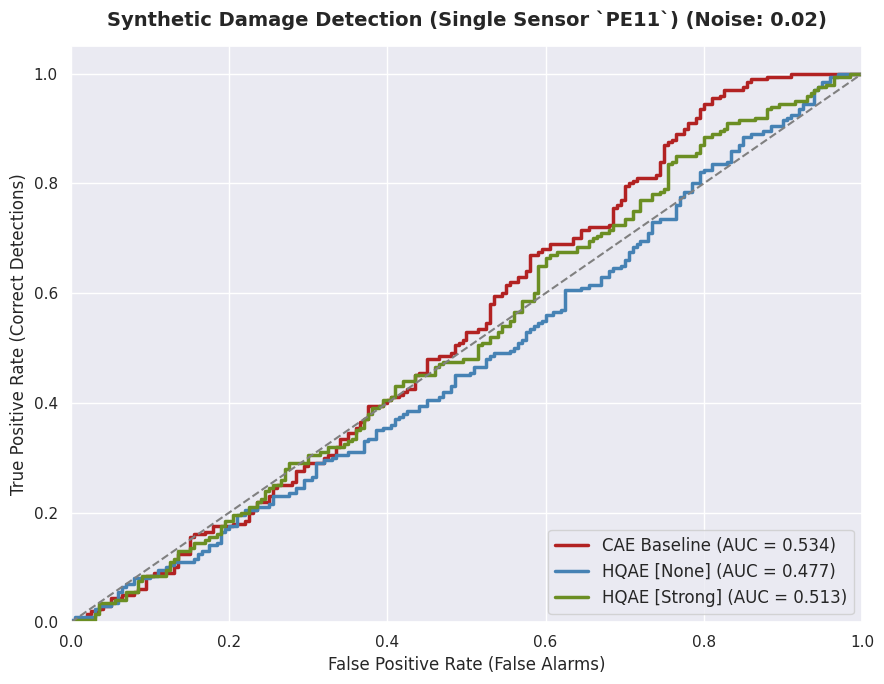

In [6]:
current_noise = 0.02

# 1. Classical Convolutional Autoencoder (CAE Baseline)
cae_auc, cae_std, cae_scores, y_true = evaluate_model_ensemble(
    model_class=ClassicalAutoencoder,
    model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1},
    checkpoint_folder="classical",
    noise_level=current_noise,
    weight_filename="best_cae_model.pth"
)

# 2. HQAE [Zero Entanglement]
hqae_none_auc, hqae_none_std, hqae_none_scores, _ = evaluate_model_ensemble(
    model_class=HybridQuantumAutoencoder,
    model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1, 'n_quantum_layers': 3, 'topology': 'none'},
    checkpoint_folder="quantum/none_d3",
    noise_level=current_noise
)

# 3. HQAE [Strong Entanglement]
hqae_strong_auc, hqae_strong_std, hqae_strong_scores, _ = evaluate_model_ensemble(
    model_class=HybridQuantumAutoencoder,
    model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1, 'n_quantum_layers': 3, 'topology': 'strong'},
    checkpoint_folder="quantum/strong_d3",
    noise_level=current_noise
)

# Print numerical AUC values with standard deviation to terminal
print(f" AUC-ROC Scores for Noise Level: {current_noise}")
print(f"➔ CAE Baseline: {cae_auc:.3f} ± {cae_std:.3f}")
print(f"➔ HQAE [None]: {hqae_none_auc:.3f} ± {hqae_none_std:.3f}")
print(f"➔ HQAE [Strong]: {hqae_strong_auc:.3f} ± {hqae_strong_std:.3f}\n")

plot_roc_curve(
    {
        "CAE Baseline": cae_scores,
        "HQAE [None]": hqae_none_scores,
        "HQAE [Strong]": hqae_strong_scores
    },
    y_true, title=f"Synthetic Damage Detection (Single Sensor `PE11`) (Noise: {current_noise})"
)

## **Test 2: The Phase Transition Inflection Point (3% Noise)**
* Simulates the critical boundary where localized structural fatigue begins to mathematically diverge from the global ambient variance.
* Maps the exact sensitivity threshold of the architectures + helps determine where the continuous quantum regularization overcomes the classical environmental noise floor.

 AUC-ROC Scores for Noise Level: 0.03
➔ CAE Baseline: 0.525 ± 0.034
➔ HQAE [None]: 0.484 ± 0.013
➔ HQAE [Strong]: 0.609 ± 0.007



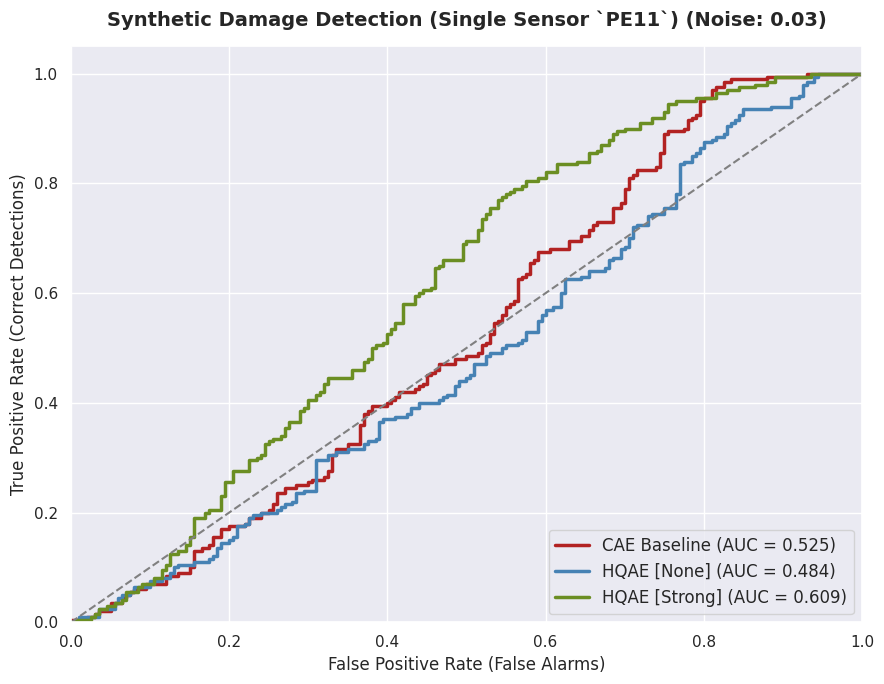

In [7]:
current_noise = 0.03

cae_auc, cae_std, cae_scores, y_true = evaluate_model_ensemble(
    model_class=ClassicalAutoencoder, model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1},
    checkpoint_folder="classical", noise_level=current_noise, weight_filename="best_cae_model.pth"
)

hqae_none_auc, hqae_none_std, hqae_none_scores, _ = evaluate_model_ensemble(
    model_class=HybridQuantumAutoencoder, model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1, 'n_quantum_layers': 3, 'topology': 'none'},
    checkpoint_folder="quantum/none_d3", noise_level=current_noise
)

hqae_strong_auc, hqae_strong_std, hqae_strong_scores, _ = evaluate_model_ensemble(
    model_class=HybridQuantumAutoencoder, model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1, 'n_quantum_layers': 3, 'topology': 'strong'},
    checkpoint_folder="quantum/strong_d3", noise_level=current_noise
)

print(f" AUC-ROC Scores for Noise Level: {current_noise}")
print(f"➔ CAE Baseline: {cae_auc:.3f} ± {cae_std:.3f}")
print(f"➔ HQAE [None]: {hqae_none_auc:.3f} ± {hqae_none_std:.3f}")
print(f"➔ HQAE [Strong]: {hqae_strong_auc:.3f} ± {hqae_strong_std:.3f}\n")

plot_roc_curve(
    {"CAE Baseline": cae_scores, "HQAE [None]": hqae_none_scores, "HQAE [Strong]": hqae_strong_scores},
    y_true, title=f"Synthetic Damage Detection (Single Sensor `PE11`) (Noise: {current_noise})"
)

## **Test 3: Pre-Yield Stiffness Loss (4% Noise)**
* Simulates the final stage of incipient degradation immediately prior to the emergence of macroscopically visible cracking or localized element yielding.
* Tests the single-sensor model's ability to cleanly separate the developing damage manifold before the structural anomaly becomes trivial to detect.

 AUC-ROC Scores for Noise Level: 0.04
➔ CAE Baseline: 0.532 ± 0.032
➔ HQAE [None]: 0.510 ± 0.017
➔ HQAE [Strong]: 0.736 ± 0.010



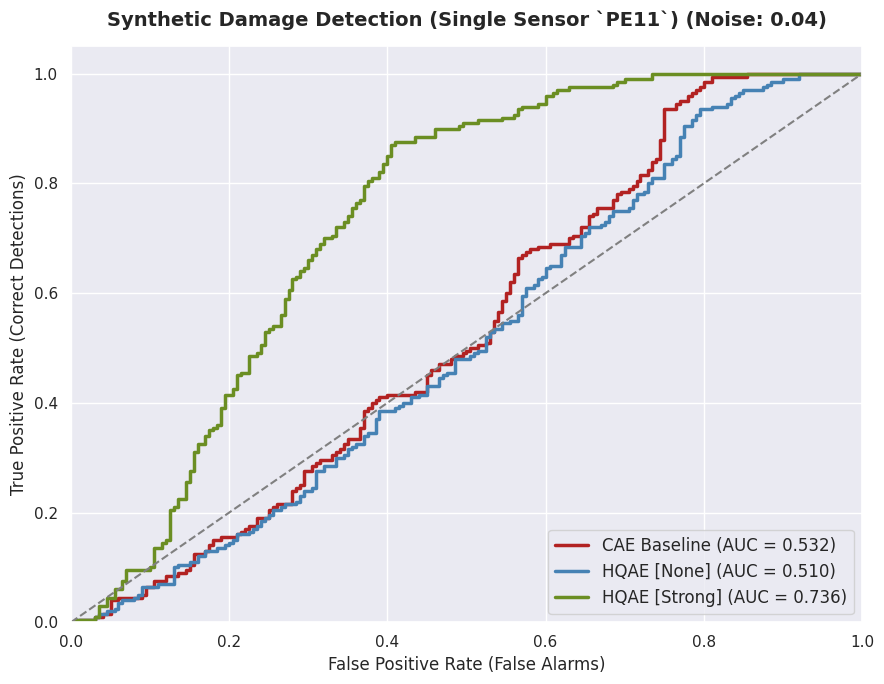

In [8]:
current_noise = 0.04

cae_auc, cae_std, cae_scores, y_true = evaluate_model_ensemble(
    model_class=ClassicalAutoencoder, model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1},
    checkpoint_folder="classical", noise_level=current_noise, weight_filename="best_cae_model.pth"
)

hqae_none_auc, hqae_none_std, hqae_none_scores, _ = evaluate_model_ensemble(
    model_class=HybridQuantumAutoencoder, model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1, 'n_quantum_layers': 3, 'topology': 'none'},
    checkpoint_folder="quantum/none_d3", noise_level=current_noise
)

hqae_strong_auc, hqae_strong_std, hqae_strong_scores, _ = evaluate_model_ensemble(
    model_class=HybridQuantumAutoencoder, model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1, 'n_quantum_layers': 3, 'topology': 'strong'},
    checkpoint_folder="quantum/strong_d3", noise_level=current_noise
)

print(f" AUC-ROC Scores for Noise Level: {current_noise}")
print(f"➔ CAE Baseline: {cae_auc:.3f} ± {cae_std:.3f}")
print(f"➔ HQAE [None]: {hqae_none_auc:.3f} ± {hqae_none_std:.3f}")
print(f"➔ HQAE [Strong]: {hqae_strong_auc:.3f} ± {hqae_strong_std:.3f}\n")

plot_roc_curve(
    {"CAE Baseline": cae_scores, "HQAE [None]": hqae_none_scores, "HQAE [Strong]": hqae_strong_scores},
    y_true, title=f"Synthetic Damage Detection (Single Sensor `PE11`) (Noise: {current_noise})"
)

## **Test 4: Intermediate Structural Degradation (5% Noise)**
* Simulates active, progressing deterioration (such as concrete spalling or minor rebar yielding) where the localized stiffness loss definitively breaches the environmental noise floor.
* Evaluates the capacity of the network to cleanly isolate the localized damage signature without the benefit of spatial geometry context.

 AUC-ROC Scores for Noise Level: 0.05
➔ CAE Baseline: 0.539 ± 0.035
➔ HQAE [None]: 0.555 ± 0.014
➔ HQAE [Strong]: 0.849 ± 0.003



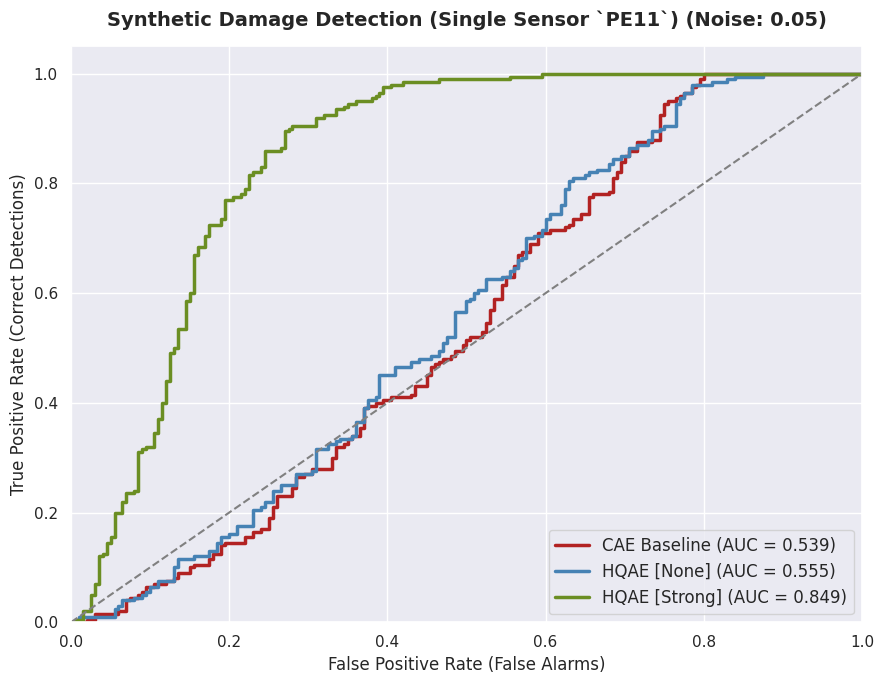

In [9]:
current_noise = 0.05

cae_auc, cae_std, cae_scores, y_true = evaluate_model_ensemble(
    model_class=ClassicalAutoencoder, model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1},
    checkpoint_folder="classical", noise_level=current_noise, weight_filename="best_cae_model.pth"
)

hqae_none_auc, hqae_none_std, hqae_none_scores, _ = evaluate_model_ensemble(
    model_class=HybridQuantumAutoencoder, model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1, 'n_quantum_layers': 3, 'topology': 'none'},
    checkpoint_folder="quantum/none_d3", noise_level=current_noise
)

hqae_strong_auc, hqae_strong_std, hqae_strong_scores, _ = evaluate_model_ensemble(
    model_class=HybridQuantumAutoencoder, model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1, 'n_quantum_layers': 3, 'topology': 'strong'},
    checkpoint_folder="quantum/strong_d3", noise_level=current_noise
)

print(f" AUC-ROC Scores for Noise Level: {current_noise}")
print(f"➔ CAE Baseline: {cae_auc:.3f} ± {cae_std:.3f}")
print(f"➔ HQAE [None]: {hqae_none_auc:.3f} ± {hqae_none_std:.3f}")
print(f"➔ HQAE [Strong]: {hqae_strong_auc:.3f} ± {hqae_strong_std:.3f}\n")

plot_roc_curve(
    {"CAE Baseline": cae_scores, "HQAE [None]": hqae_none_scores, "HQAE [Strong]": hqae_strong_scores},
    y_true, title=f"Synthetic Damage Detection (Single Sensor `PE11`) (Noise: {current_noise})"
)

## **Test 5: Advanced Localized Failure (10% Noise)**
* Simulates severe deterioration nearing a catastrophic threshold $\rightarrow$ represents a critical loss of localized load-bearing capacity.
* Establishes the upper-bound benchmark for manifold separation.

 AUC-ROC Scores for Noise Level: 0.1
➔ CAE Baseline: 0.725 ± 0.058
➔ HQAE [None]: 0.823 ± 0.059
➔ HQAE [Strong]: 0.998 ± 0.001



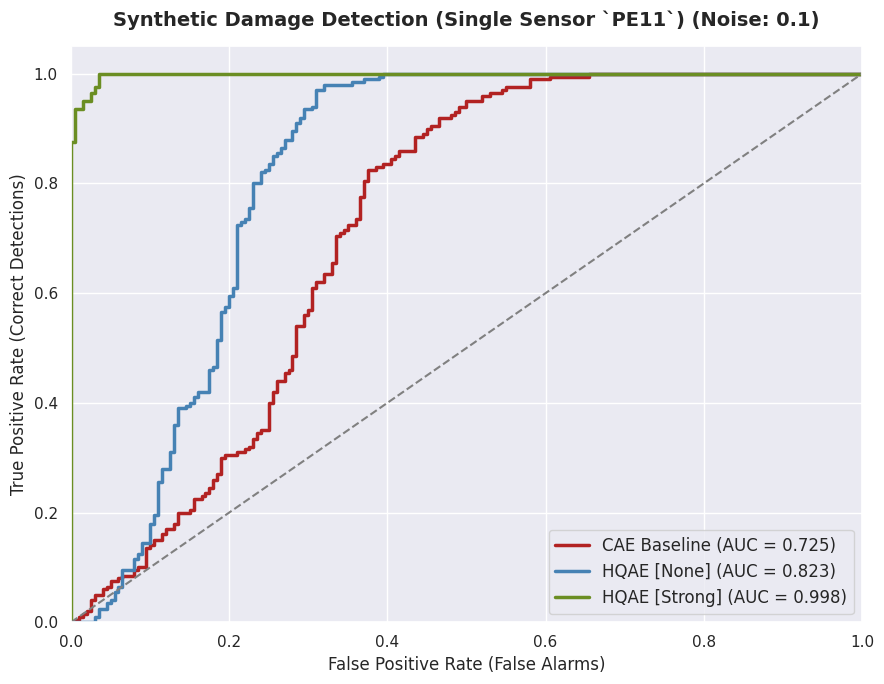

In [10]:
current_noise = 0.10

cae_auc, cae_std, cae_scores, y_true = evaluate_model_ensemble(
    model_class=ClassicalAutoencoder, model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1},
    checkpoint_folder="classical", noise_level=current_noise, weight_filename="best_cae_model.pth"
)

hqae_none_auc, hqae_none_std, hqae_none_scores, _ = evaluate_model_ensemble(
    model_class=HybridQuantumAutoencoder, model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1, 'n_quantum_layers': 3, 'topology': 'none'},
    checkpoint_folder="quantum/none_d3", noise_level=current_noise
)

hqae_strong_auc, hqae_strong_std, hqae_strong_scores, _ = evaluate_model_ensemble(
    model_class=HybridQuantumAutoencoder, model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1, 'n_quantum_layers': 3, 'topology': 'strong'},
    checkpoint_folder="quantum/strong_d3", noise_level=current_noise
)

print(f" AUC-ROC Scores for Noise Level: {current_noise}")
print(f"➔ CAE Baseline: {cae_auc:.3f} ± {cae_std:.3f}")
print(f"➔ HQAE [None]: {hqae_none_auc:.3f} ± {hqae_none_std:.3f}")
print(f"➔ HQAE [Strong]: {hqae_strong_auc:.3f} ± {hqae_strong_std:.3f}\n")

plot_roc_curve(
    {"CAE Baseline": cae_scores, "HQAE [None]": hqae_none_scores, "HQAE [Strong]": hqae_strong_scores},
    y_true, title=f"Synthetic Damage Detection (Single Sensor `PE11`) (Noise: {current_noise})"
)

## **Empirical Observations**

This Phase 3 ablation study establishes the physical and architectural limits of localized Structural Health Monitoring (SHM).

We can empirically define where a single sensor fails to provide sufficient structural context by analyzing both the ensembled AUC-ROC and the standard deviation (±) across multiple initialization seeds.

### **1. The Single-Sensor Sensitivity Floor (2% - 3% Degradation)**
At the 2% and 3% degradation thresholds $\rightarrow$ the structural anomaly is statistically indistinguishable from ambient environmental variance.
* Classical CAE functions near random guessing (AUC 0.534 ± 0.039 at 2%).
* Heavily entangled quantum architecture `HQAE Strong` also fails to separate the manifolds at 2% (AUC 0.513 ± 0.002).
* **Inference:**
  * A single accelerometer lacks the requisite spatial context to differentiate incipient micro-cracking from routine global variance (e.g., thermal expansion, wind loads).
  * Both classical and quantum autoencoders correctly process this 2% variance as normal baseline activity $\leftarrow$ establish a hard sensitivity floor for localized sensing.

### **2. Quantum Feature Separation (4% - 5% Degradation)**
Between 4% and 5% degradation $\rightarrow$ the simulated damage signature begins to exceed the ambient noise floor.
* The classical CAE fails entirely:
  * It stagnates at 0.539 ± 0.035 even at 5% damage.
  * It lacks the parameter efficiency to mathematically separate the emerging damage manifold from the environmental noise.
* The `HQAE [Strong]` architecture successfully isolates the damage:
  * It achieves an AUC of 0.736 ± 0.010 at 4% and 0.849 ± 0.003 at 5%.
* **Inference:**
  * Quantum entanglement provides superior feature extraction for continuous vibration data.
  * Furthermore, the exceptionally tight standard deviation (±0.003 at 5%) indicates high initialization stability and resilience against Barren Plateaus.
  * However, this quantum advantage only materializes after the structural degradation becomes relatively pronounced.

## **Conclusion (Pivot to Spatial Graph Fusion)**
The Phase 3 data prove a fundamental physical limitations:
* **A single node cannot detect incipient damage without triggering false positives**
* **A single physical accelerometer lacks the requisite Signal-to-Noise Ratio (SNR) and spatial context to differentiate incipient localized damage from global environmental vibration.**

If a single sensor cannot determine whether a 2% variance is a micro-crack or a temperature shift, the system must establish a global geometric baseline.

Phase 4 will transition to a 6-sensor spatial fusion architecture to evaluate if multi-node phase correlation can isolate localized anomalies hidden within global noise.